### Quadratic Trough test case

</b> Author:   </b>  Sam MacKay

In [1]:
import jax_init

import os

#top_level_path = resolve_path(str(os.path.dirname(os.path.realpath(__file__))) + "/../")
top_level_path = os.path.abspath(os.path.join(os.getcwd(), '../../src'))
print("Setting top level path for imports:", top_level_path)

# Ensure top-level path is in sys.path
if top_level_path not in sys.path:
    # makes sure top level directory path is present in system so that relative imports work
    sys.path.insert(0, top_level_path)

# if enable_x64 is set in jax_init, will have to set manually in slimline too
import slimline as solver

import importlib
importlib.reload(solver)

import numpy as np
import matplotlib.pyplot as plt


Disabling python multi-threading...
Initialising jax...

Default jax backend: cpu
Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13), CpuDevice(id=14), CpuDevice(id=15)]
Setting top level path for imports: /home/administrator/Programs/synthPy/src


Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 14.982200622558594 GB
 - free  : 4.560070037841797 GB
 - used  : 10.501270294189453 GB

Est. domain memory limit: 17.6 MB
 --> inc. +10.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Generating test Generating field for the Quadratic Trough test case...


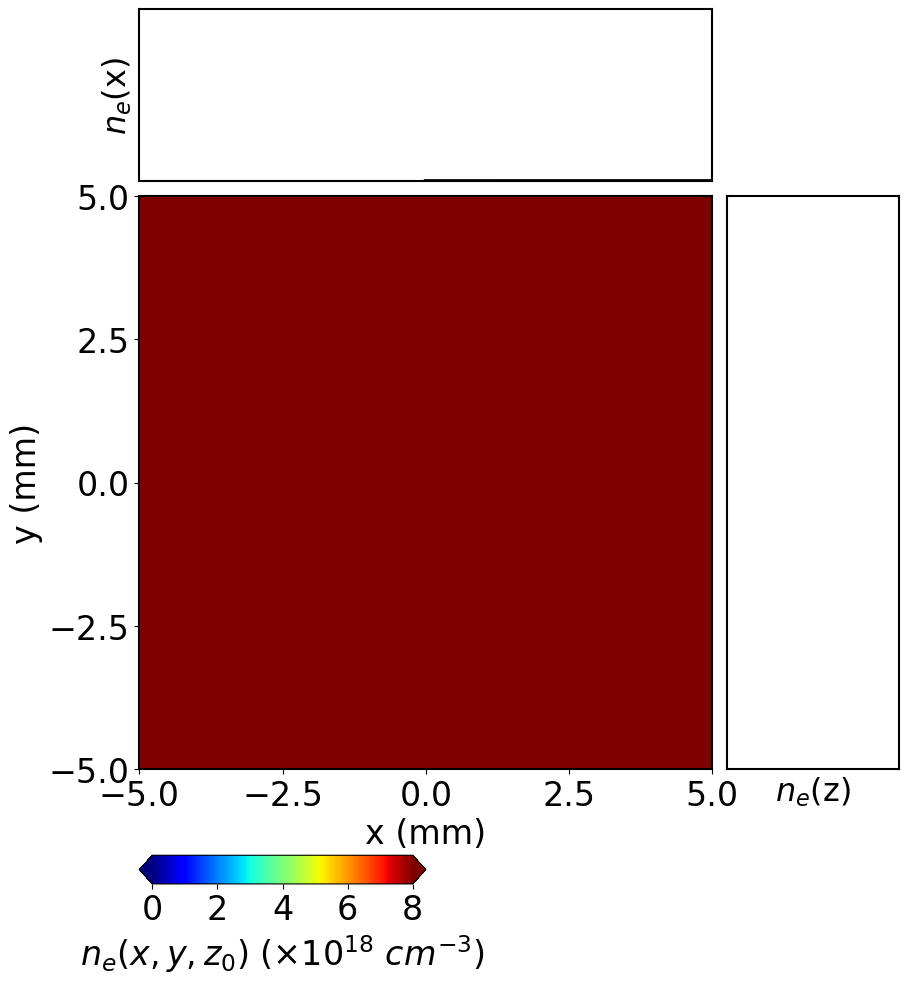

In [2]:
# define some extent, the domain should be distributed as +extent to -extent, does not need to be cubic
extent_x = 25e-2
extent_y = 5e-2
extent_z = 10e-3

n_cells = 128

probing_extent = extent_z
probing_direction = 'z'

lengths = 2 * np.array([extent_x, extent_y, extent_z])
domain = solver.ScalarDomain(lengths, n_cells, ne_type = "quad_trough_test", probing_direction = probing_direction, mirrored = False)

from processing.plotting import graph_domain
graph_domain(domain)

In [3]:
lwl = 351e-9 #define laser wavelength

# initialise beam
Np = 1    # number of photons
divergence = 5e-5   # realistic divergence value
beam_size = extent_y    # beam radius
ne_extent = probing_extent  # so the beam knows where to initialise initial positions
beam_type = 'circular'

beam_definition = solver.Beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = "circular",
    offset = (125e-3, 25e-3, 0)
)

In [7]:
#output timestepped saved values
# do analysis

rf, duration = solver.solve(beam_definition.s0, domain, probing_extent)


Number of domain batches: 1
Number of ray batches: 1

Est. size in memory of rays (1 = 712 B): 712 B
 --> Np = 1

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.01 mm's to the target depth of 0.01 mm's

Running device: cpu, with: 16 cores.
Not enough rays to parallelise over cores: increase to at least 16 to utilise parallelisation
 --> Running CPU processes sequentially

Completed ray trace in 1.962 seconds.

Parallelised output has resulting 3D matrix of form: [batch_count, (save_points_per_region - 1) * ScalarDomain.region_count, 9]: (1, 2, 9)
 - 2 to account for the start and end results (typical, can be greater if set)
 - 9 containing the 3 position and velocity components, amplitude, phase and polarisation
 - If batch_count is lower than expected, this is likely due to jax's forced integer batch sharding requirement over cpu cores.

We slice the results and transpose into the form: (1, 2, 9) to work with later code.
[[ 7.6310322e


All rays incident on lens!

rf size expected: [0. 0.]
rf after clearing nan's: [0. 0.]

All rays incident on lens!

rf size expected: [0. 0.]
rf after clearing nan's: [0. 0.]


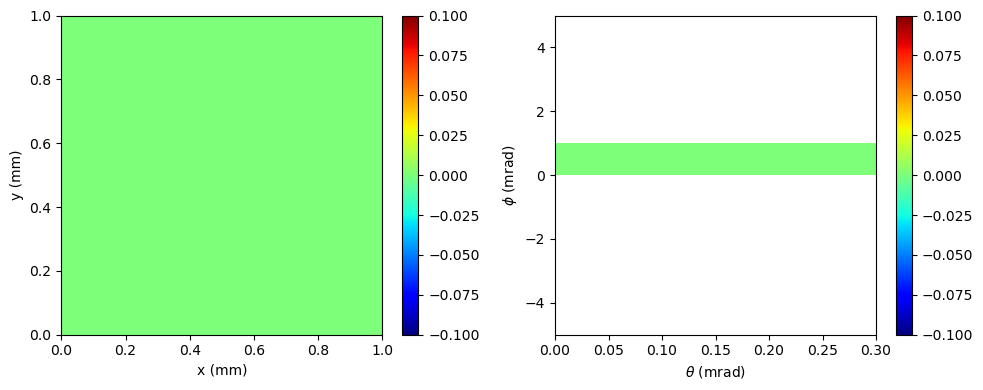

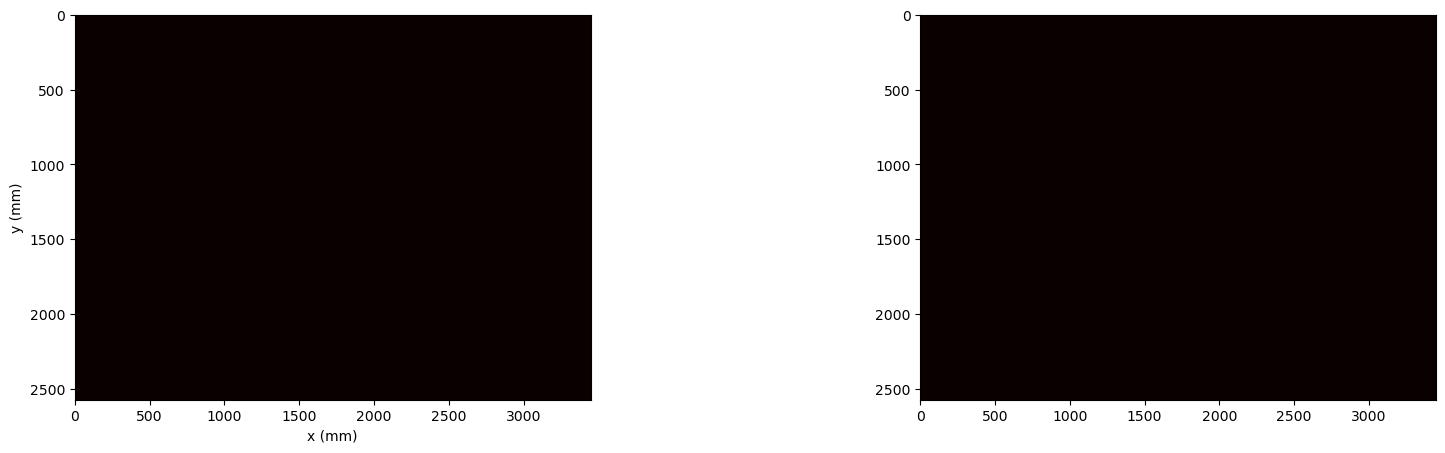

In [5]:
from processing.plotting import general_ray_plots
general_ray_plots(rf, n_cells, lwl = lwl)


1 rays received, 0 incident on the first lens.
 --> 100.0 % of rays wasted!

rf size expected: [0. 0.]
rf after clearing nan's: [0. 0.]


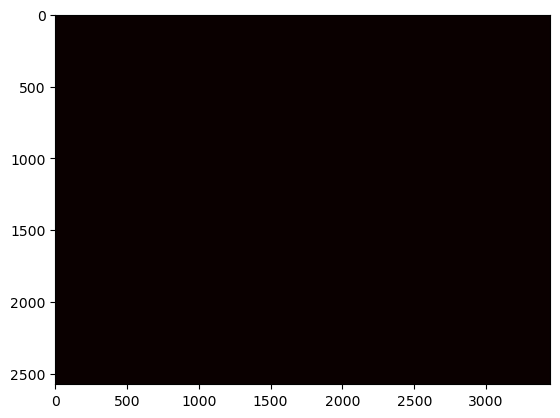

In [6]:
#in the diagnostic initialisation, details on the lens configurations, and detector dimensions can be specified
refractometer = solver.Refractometry(lwl, rf)
# cam't clear_mem if you want to generate other graphs afterwards
refractometer.plot_rays(bin_scale = 1, clear_mem = True)
#
plt.imshow(refractometer.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))
plt.show()